# Spendable — Stage 3: Cash-Flow Forecasting & Short-Term Liquidity Trajectories

## 1. Overview & Core Objectives

Given observable features and detected recurring commitments up to snapshot time $T$, Stage 3 forecasts the user's future account balance trajectory and short-term minimum liquidity over **7, 14, and 30-day horizons**.\n
### Core System Principles
- **Forecast Minimum Balance**: Primary target is `future_min_balance` ($H=7, 14, 30$ days), predicting how low liquidity will fall.
- **Strict Point-in-Time Non-Leakage**: Features use ONLY transactions occurring at or before $T$ ($t \le T$). Future events are strictly isolated.
- **Baseline vs ML Comparison**: Evaluates Rolling Average Baseline and Recurring Commitment Baseline against a supervised `HistGradientBoostingRegressor` ML model.
- **User Partition Isolation**: Model trained on `TRAIN` (350 users), hyperparameter decisions selected on `VALIDATION` (75 users), and final evaluation reported on `TEST` (75 users).

In [1]:
import sys
from pathlib import Path
import json
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Add backend to sys.path
backend_path = Path('../backend').resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

from app.forecasting.pipeline import ForecastingPipeline
from app.forecasting.baselines import RollingAverageBaseline, RecurringCommitmentBaseline
from app.forecasting.models import CashFlowForecastModel
from app.forecasting.evaluator import ForecastingEvaluator

sns.set_theme(style='whitegrid')
print('Forecasting module imported successfully!')

Forecasting module imported successfully!


## 2. Load Partitioned Feature Splits & Ground Truth

Load exported point-in-time snapshot feature matrices across 500 user accounts.

In [2]:
data_dir = Path('../data')
pipeline = ForecastingPipeline(str(data_dir))
df_train, df_val, df_test = pipeline.load_feature_splits()

gt_path = data_dir / 'ground_truth.json'
gt_data = {}
if gt_path.exists():
    with open(gt_path, 'r', encoding='utf-8') as f:
        gt_data = json.load(f)

print(f'TRAIN Feature Snapshots     : {len(df_train):,}')
print(f'VALIDATION Feature Snapshots: {len(df_val):,}')
print(f'TEST Feature Snapshots      : {len(df_test):,}')

TRAIN Feature Snapshots     : 7,685
VALIDATION Feature Snapshots: 1,647
TEST Feature Snapshots      : 1,649


## 3. Fit ML Model & Evaluate Baseline vs ML Models on VALIDATION

Fit `HistGradientBoostingRegressor` on `TRAIN` and compare against baselines on `VALIDATION` split.

In [3]:
base_rolling = RollingAverageBaseline()
base_recurring = RecurringCommitmentBaseline()
ml_model = CashFlowForecastModel(random_seed=42)

ml_model.fit(df_train)
evaluator = ForecastingEvaluator(safety_threshold_bdt=15000.0)

summary_rolling = evaluator.evaluate_model(base_rolling, df_val, 'VALIDATION', gt_data)
summary_recurring = evaluator.evaluate_model(base_recurring, df_val, 'VALIDATION', gt_data)
summary_ml = evaluator.evaluate_model(ml_model, df_val, 'VALIDATION', gt_data)

val_rows = []
for m in [summary_rolling, summary_recurring, summary_ml]:
    for H, reg_m in zip((7, 14, 30), (m.metrics_7d, m.metrics_14d, m.metrics_30d)):
        val_rows.append({
            'Model': m.model_name,
            'Horizon': f'{H}d',
            'MAE (BDT)': reg_m.mae,
            'RMSE (BDT)': reg_m.rmse,
            'R2 Score': reg_m.r2_score,
            'Pressure F1 (30d)': m.pressure_metrics_30d.f1_score if H == 30 else None,
        })

df_val_comp = pd.DataFrame(val_rows)
print('=== VALIDATION SET MODEL COMPARISON ===')
display(df_val_comp)

=== VALIDATION SET MODEL COMPARISON ===


,Model,Horizon,MAE (BDT),RMSE (BDT),R2 Score,Pressure F1 (30d)
0,ROLLING_AVERAGE_BASELINE,7d,16972.14,33429.98,0.99,NaN
1,ROLLING_AVERAGE_BASELINE,14d,22148.81,35123.09,0.99,NaN
2,ROLLING_AVERAGE_BASELINE,30d,28418.56,41137.53,0.99,0.66
3,RECURRING_COMMITMENT_BASELINE,7d,16842.70,32759.45,0.99,NaN
4,RECURRING_COMMITMENT_BASELINE,14d,21926.65,33987.57,0.99,NaN
5,RECURRING_COMMITMENT_BASELINE,30d,27750.43,38998.73,0.99,0.62
6,HIST_GRADIENT_BOOSTING,7d,15429.47,28354.90,0.99,NaN
7,HIST_GRADIENT_BOOSTING,14d,15655.88,27274.81,0.99,NaN
8,HIST_GRADIENT_BOOSTING,30d,15873.29,26436.34,0.99,0.83


## 4. Final Unbiased Evaluation on TEST Set (Selected ML Model)

Evaluate selected `HistGradientBoostingRegressor` model on unbiased `TEST` split.

In [4]:
test_summary = evaluator.evaluate_model(ml_model, df_test, 'TEST', gt_data)

test_rows = []
for H, reg_m in zip((7, 14, 30), (test_summary.metrics_7d, test_summary.metrics_14d, test_summary.metrics_30d)):
    test_rows.append({
        'Horizon': f'{H}d',
        'MAE (BDT)': reg_m.mae,
        'RMSE (BDT)': reg_m.rmse,
        'R2 Score': reg_m.r2_score,
        'Pressure Precision (30d)': test_summary.pressure_metrics_30d.precision if H == 30 else None,
        'Pressure Recall (30d)': test_summary.pressure_metrics_30d.recall if H == 30 else None,
        'Pressure F1 (30d)': test_summary.pressure_metrics_30d.f1_score if H == 30 else None,
    })

df_test_res = pd.DataFrame(test_rows)
print('=== UNBIASED TEST SET EVALUATION (ML MODEL) ===')
display(df_test_res)

=== UNBIASED TEST SET EVALUATION (ML MODEL) ===


,Horizon,MAE (BDT),RMSE (BDT),R2 Score,Pressure Precision (30d),Pressure Recall (30d),Pressure F1 (30d)
0,7d,13982.08,24685.64,0.99,NaN,NaN,NaN
1,14d,13907.12,23437.21,1.00,NaN,NaN,NaN
2,30d,14682.01,23903.56,0.99,0.92,0.82,0.87


## 5. Performance Breakdown by User Persona

Analyze 30-day forecast errors and low-balance pressure anticipation across user persona profiles.

In [5]:
persona_rows = []
for pm in test_summary.persona_breakdown:
    persona_rows.append({
        'Persona': pm.persona,
        'Snapshots': pm.total_snapshots,
        'MAE 30d (BDT)': pm.mae_30d,
        'RMSE 30d (BDT)': pm.rmse_30d,
        'Pressure F1': pm.pressure_f1_30d,
    })

df_persona = pd.DataFrame(persona_rows)
print('=== TEST SET PERSONA PERFORMANCE BREAKDOWN ===')
display(df_persona)

=== TEST SET PERSONA PERFORMANCE BREAKDOWN ===


,Persona,Snapshots,MAE 30d (BDT),RMSE 30d (BDT),Pressure F1
0,COMMITMENT_HEAVY,308,16230.30,24229.17,0.00
1,FINANCIAL_PRESSURE,110,15744.92,22239.99,0.00
2,IRREGULAR_INCOME,263,27582.89,38486.29,0.29
3,SPENDING_DRIFT,220,11610.09,17956.51,0.00
4,STABLE,374,14791.03,24062.88,0.00
5,TIGHT_LIQUIDITY,374,5720.32,8947.49,0.95


## 6. Feature Importance & Model Explainability

Inspect top permutation feature importances for 30-day minimum balance prediction.

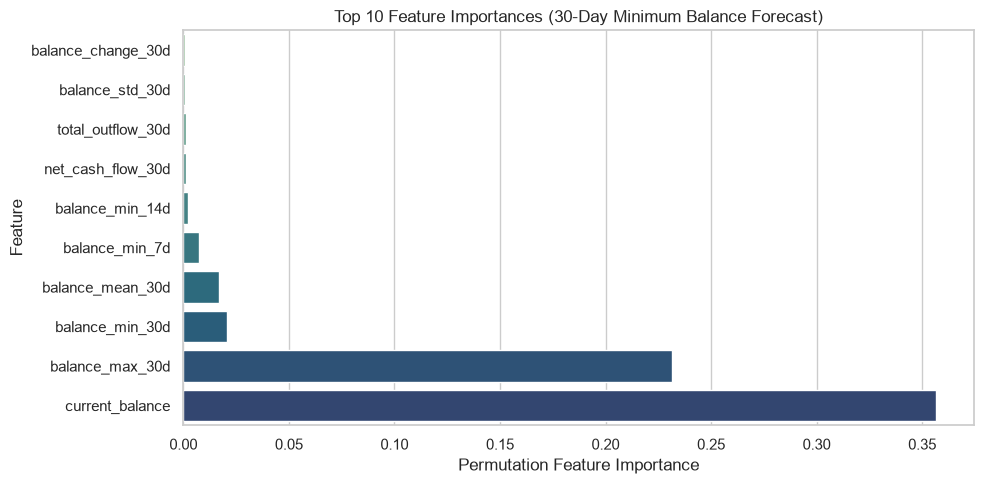

In [6]:
feat_imp = evaluator.compute_feature_importance(ml_model, df_val, horizon_days=30, top_n=10)
df_imp = pd.DataFrame(list(feat_imp.items()), columns=['Feature', 'Importance']).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_imp, y='Feature', x='Importance', palette='crest', hue='Feature', legend=False)
plt.title('Top 10 Feature Importances (30-Day Minimum Balance Forecast)')
plt.xlabel('Permutation Feature Importance')
plt.tight_layout()
plt.show()

## 7. Sample User Projected Daily Trajectory (`ACC-0001`)

Plot 30-day projected daily liquidity trajectory for sample user `ACC-0001`.

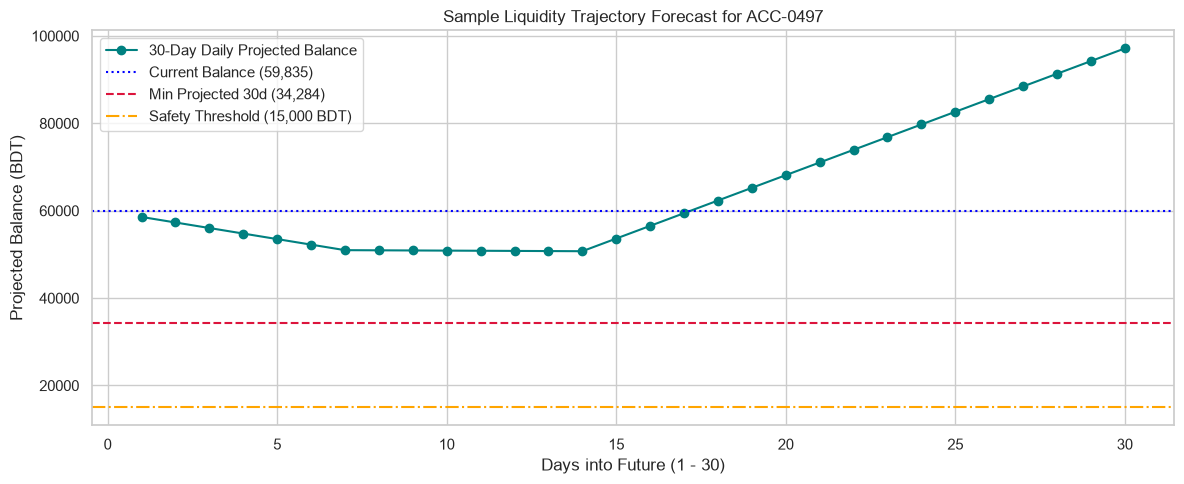

In [7]:
acc1_row = df_test.iloc[0].to_dict()
f_acc1 = ml_model.predict_snapshot(acc1_row, safety_threshold_bdt=15000.0)

traj_days = [pt.day_offset for pt in f_acc1.daily_trajectory]
traj_bals = [pt.projected_balance for pt in f_acc1.daily_trajectory]

plt.figure(figsize=(12, 5))
plt.plot(traj_days, traj_bals, marker='o', color='teal', label='30-Day Daily Projected Balance')
plt.axhline(f_acc1.current_balance, color='blue', linestyle=':', label=f'Current Balance ({f_acc1.current_balance:,.0f})')
plt.axhline(f_acc1.forecast_30d.minimum_projected_balance, color='crimson', linestyle='--', label=f'Min Projected 30d ({f_acc1.forecast_30d.minimum_projected_balance:,.0f})')
plt.axhline(15000.0, color='orange', linestyle='-.', label='Safety Threshold (15,000 BDT)')
plt.title(f'Sample Liquidity Trajectory Forecast for {f_acc1.user_id}')
plt.xlabel('Days into Future (1 - 30)')
plt.ylabel('Projected Balance (BDT)')
plt.legend()
plt.tight_layout()
plt.show()